## 双比特 CNOT 门脉冲优化 


### 目录
1. [问题描述](###问题描述)
2. [解决方案](###解决方案)
3. [实验结果](###实验结果)
    - [基于高斯脉冲的优化](#基于高斯脉冲的优化)
    - [基于封闭系统最优脉冲的优化](#基于封闭系统最优脉冲的优化)
    - [脉冲鲁棒性](#脉冲鲁棒性)
    - [最佳脉冲](#最佳脉冲)
4. [经验总结](#经验总结)


### 问题描述



### 解决方案

我们采用**两阶段优化策略**进行双比特CNOT门脉冲优化：

1. 封闭系统优化阶段：使用GRAPE算法在理想环境下优化脉冲；
2. 开放系统优化阶段：基于封闭系统最优脉冲，使用SPSA算法在噪声环境下进行鲁棒性优化；


##### 核心特点：

1. **封闭系统优化**：使用JAX加速的GRAPE算法，在无噪声环境下获得高保真度脉冲，获得开放系统优化的良好起点；

2. **物理约束处理**：使用tanh函数将优化变量映射到[-Amax, Amax]范围内，满足最大幅度限制；

3. **直接脉冲优化**： CNOTPulseOptimizer 类采用直接脉冲优化策略，在300个脉冲步长上进行优化（600维参数空间），相比参数化方案（样条函数、傅立叶变换、线性插值等）效果无太大差别；

4. **鲁棒性设计**：对多个随机种子取平均分数作为优化目标，增强脉冲对系统参数波动的鲁棒性。当前采用单随机种子进行优化，保证计算效率；


##### 优化流程：
1. **初始脉冲生成**：
- 封闭系统最优脉冲：基于GRAPE算法在理想环境下获得高保真度脉冲作为优化起点；
- 高斯脉冲：使用高斯脉冲作为初始点，初始评分约0.39分，较难优化；

2. **物理约束**：使用tanh函数将优化变量映射到特定范围；

3. **SPSA迭代优化**：
- 扰动生成：每次迭代生成随机扰动向量；
- 梯度估计：通过正负扰动评估分数变化；
- 参数更新：基于估计梯度方向更新优化变量；
- 收敛监控：监控目标函数分数变化，直到满足收敛条件；

4. **性能评估**：使用多进程并行计算 100 次不同脉冲在不同随机种子下的评分，决定哪个脉冲作为最优脉冲；

### 运行展示

- 运行设备：Macmini M4
- 内存：16 GB


In [1]:
# 导入必备的库
import numpy as np
from multiprocessing import Pool, cpu_count
import time
import json

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="qutip")

import matplotlib.pyplot as plt
from matplotlib import rcParams
# 设置中文字体支持
rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
rcParams['axes.unicode_minus'] = False

# 加载优化相关的函数
from cnot_spsa_utils import generate_initial_pulse, CNOTPulseOptimizer, evaluate_pulse
from cnot_spsa_utils import plot_pulses, plot_iter_hist, extract_scores_from_iter_hist
# 对原始评分器进行了优化，可以使用多进程并行计算
from two_transmon_grader import DispersiveCNOTPulseGrader

# 从封闭系统的代码中加载函数
from cnot_closed import cosine_pulse, TwoQubitGRAPE

首先，我们先设置初始评分器。与单比特评分器一样，我们对官方的代码进行了修改，在 `DispersiveCNOTPulseGrader` 类中添加了参数 `computing_method = 'parallel' or 'serial'`，可选择多进程计算 36 个初始量子态在当前脉冲下的演化，加快运行速度。在我们的 spsa 优化中，原始串行计算，完成一次迭代优化大约需要 780 秒，而多进程需 80 秒，提升 10 倍左右。与原评分器的性能对比，可见文件 `cnot_compare.ipynb` ，其中出值结果是一致的。

In [2]:
# 设置评分器
grader = DispersiveCNOTPulseGrader(
    nq_levels=3,
    n_steps=300,
    dt=5e-10,          # 0.5 ns
    T1_q1=50e-6,
    T1_q2=50e-6,
    Tphi_q1=30e-6,
    Tphi_q2=30e-6,
    nbar_q1=0.0,
    nbar_q2=0.0,
    sigma_detune_q1_Hz=0.5e6,  # 0.5 MHz
    sigma_detune_q2_Hz=0.5e6,  # 0.5 MHz
    n_shots=10,        # 默认评分shots
    h_a_Hz=200e6,
    h_d_Hz=2.7e6,
    A_penalty=0.1,
    computing_method='parallel' # 评分采用并行计算
)

# 相位
n_shots = 10
iters = 50 # 迭代次数

##### 基于高斯脉冲的优化

使用 `generate_initial_pulse` 函数生成一个高斯脉冲作为初始脉冲，随后使用 `CNOTPulseOptimizer` 类基于 spsa 方案对脉冲进行优化，但分数基本无太大提高，保存在 0.4 分左右，如果增加迭代次数到 200 次及以上，分数能达到 0.6 左右。`CNOTPulseOptimizer` 类并未对脉冲进行参数化，实际上，我们尝试使用样条函数、傅立叶变换、单比特优化中线性插值等参数化方案，但其优化分数均无太大提高。

初始高斯脉冲的评分：0.3892


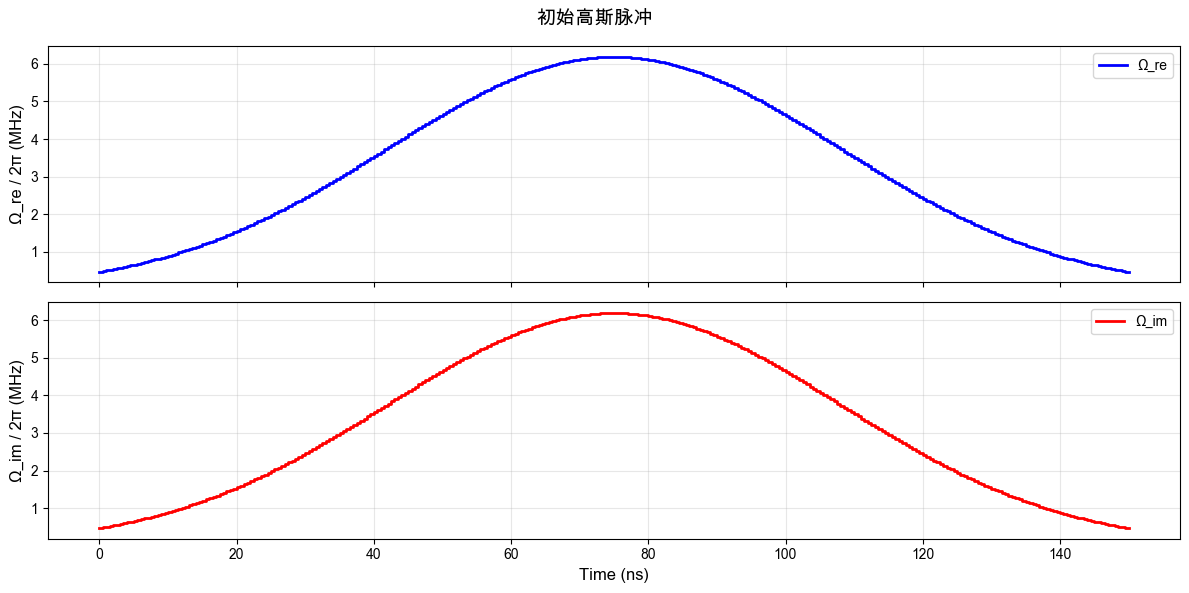

In [3]:
pulses_init_gaussian = generate_initial_pulse(grader.n_steps, grader.dt, method="gaussian", target_angle=np.pi)

plot_pulses(pulses_init_gaussian, grader.n_steps, grader.dt, title="初始高斯脉冲")

gaussian_score = grader.grade_submission(pulses_init_gaussian, n_shots=10, seed=42, verbose=False)['overall_score']
print(f"初始高斯脉冲的评分：{gaussian_score:.4f}")

In [4]:
# 定义优化器
optimizer = CNOTPulseOptimizer(
    grader=grader,
    n_steps=300,
    dt=5e-10,
    Amax_MHz=200,    # 幅度上界 200 MHz
    smooth_len=3,    # 平滑窗口，本意是在每一次迭代后对脉冲进行平滑，目前已注释平滑操作，该参数目前无用
    rng_seed=42
)

time_start = time.time()
# 开始优化, 并获得过程中的迭代记录
pulses_best_gaussian, gaussian_iter_hist = optimizer.run(
    iters=iters,
    shots=n_shots,
    seeds=[518],
    pulses_init=pulses_init_gaussian,
    file_name="gaussian",
    verbose=True # 打印每次的迭代信息
)
time_end = time.time()
print(f"高斯脉冲优化耗时：{time_end - time_start:.4f} 秒")


计算初始分数...
初始分数: 0.387548, 初始消耗时间: 18.08s
开始优化迭代...
x shape: (600,)
[SPSA] iter=   1 score=0.387547 best=0.387547 ak=2.361e-03 ck=1.000e-02 iter_time=75.20s
[SPSA] iter=   2 score=0.387547 best=0.387547 ak=2.240e-03 ck=9.324e-03 iter_time=72.08s
[SPSA] iter=   3 score=0.387558 best=0.387558 ak=2.135e-03 ck=8.950e-03 iter_time=75.34s
[SPSA] iter=   4 score=0.387671 best=0.387671 ak=2.042e-03 ck=8.693e-03 iter_time=80.54s
[SPSA] iter=   5 score=0.387674 best=0.387674 ak=1.959e-03 ck=8.500e-03 iter_time=79.81s
[SPSA] iter=   6 score=0.387674 best=0.387674 ak=1.884e-03 ck=8.345e-03 iter_time=81.52s
[SPSA] iter=   7 score=0.387681 best=0.387681 ak=1.817e-03 ck=8.216e-03 iter_time=80.88s
[SPSA] iter=   8 score=0.387736 best=0.387736 ak=1.755e-03 ck=8.106e-03 iter_time=84.03s
[SPSA] iter=   9 score=0.387837 best=0.387837 ak=1.699e-03 ck=8.010e-03 iter_time=84.19s
[SPSA] iter=  10 score=0.387898 best=0.387898 ak=1.647e-03 ck=7.925e-03 iter_time=84.02s
[SPSA] iter=  11 score=0.387900 best=0.3879

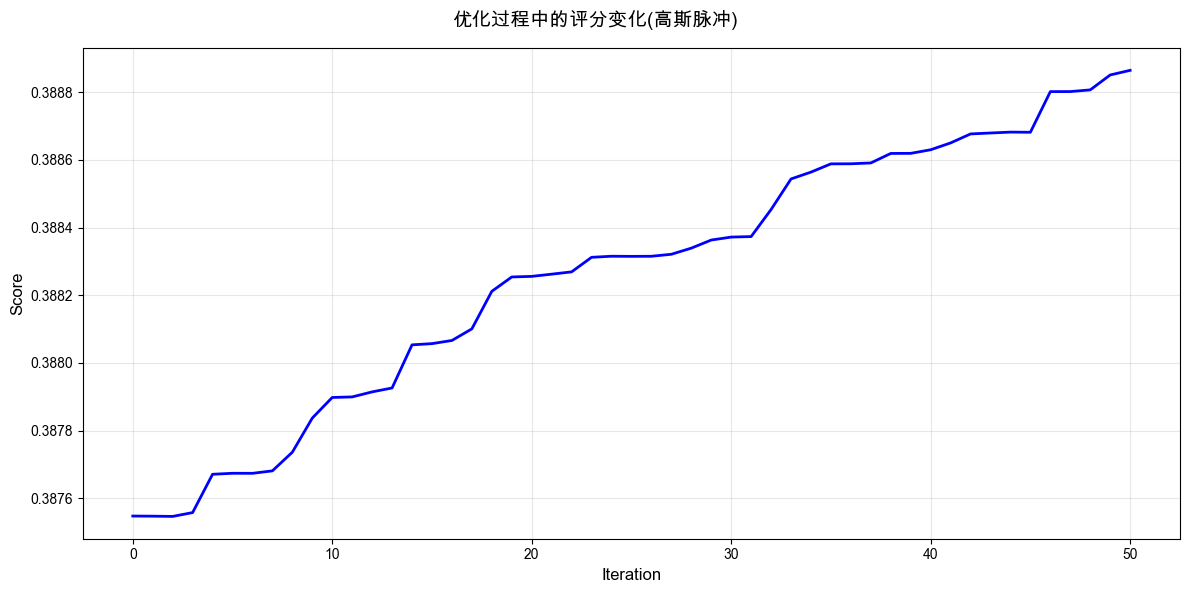

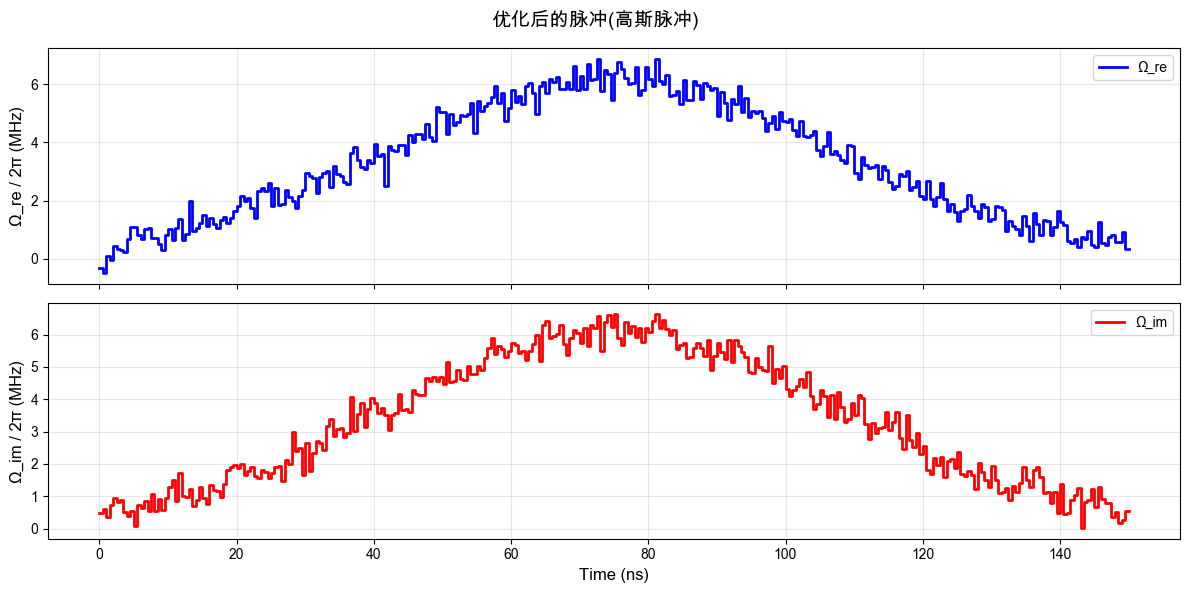

In [5]:
# 绘制迭代过程中的评分变化
plot_iter_hist(gaussian_iter_hist, title="优化过程中的评分变化(高斯脉冲)")
plot_pulses(pulses_best_gaussian, grader.n_steps, grader.dt, title="优化后的脉冲(高斯脉冲)")


##### 基于封闭系统最优脉冲的优化

使用由余弦函数构造的初始脉冲，在封闭系统中进行迭代优化，其保真度为达到 0.998905。将该脉冲放在评分器上评分，分数为 0.961586，保真度达到0.974324，说明在封闭系统上优化，得到的脉冲与目标门的保真度较高。

随后我们将该脉冲放置到开放系统使用 spsa 方案进行优化，结果发现分数基本保持不变。

同时，我们观察到一件事，在封闭系统中优化，脉冲的 Derivative Penalty 很容易溢出评分器允许的最大值 $e^{50}-1$。尽管我们在封闭系统中，添加 Derivative Penalty 分数到损失函数中，但仍然会溢出，无法保证脉冲相对平滑。或许需要像单比特脉冲优化一样，需要碰巧找到一个很好的初始平滑脉冲。

E1111 04:25:02.210384 45444897 slow_operation_alarm.cc:73] 
********************************
[Compiling module jit_cost_function for CPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
E1111 04:25:41.864956 45388126 slow_operation_alarm.cc:140] The operation took 2m39.657298s

********************************
[Compiling module jit_cost_function for CPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


Iter 0:
  Gate Fidelity: 0.264805 (Error: 0.735195)
  Leakage: 0.258988 (Score: 0.000000)
  Penalties: Amp=0.003755, Der=0.013874, Total=0.017629 (Score: 0.982371)
  Overall Score: 0.260963, |∇| = 4.94e-04
Iter 500:
  Gate Fidelity: 0.390721 (Error: 0.609279)
  Leakage: 0.210225 (Score: 0.000000)
  Penalties: Amp=0.003727, Der=0.018222, Total=0.021948 (Score: 0.978052)
  Overall Score: 0.361479, |∇| = 6.64e-04
Iter 1000:
  Gate Fidelity: 0.961030 (Error: 0.038970)
  Leakage: 0.003756 (Score: 0.981220)
  Penalties: Amp=0.003777, Der=0.699507, Total=0.703284 (Score: 0.296716)
  Overall Score: 0.930843, |∇| = 2.09e-05
Iter 1500:
  Gate Fidelity: 0.968779 (Error: 0.031221)
  Leakage: 0.001938 (Score: 0.990312)
  Penalties: Amp=0.004179, Der=0.695435, Total=0.699614 (Score: 0.300386)
  Overall Score: 0.938590, |∇| = 6.29e-06
Iter 2000:
  Gate Fidelity: 0.977563 (Error: 0.022437)
  Leakage: 0.003354 (Score: 0.983230)
  Penalties: Amp=0.004247, Der=0.565234, Total=0.569481 (Score: 0.430519)
 

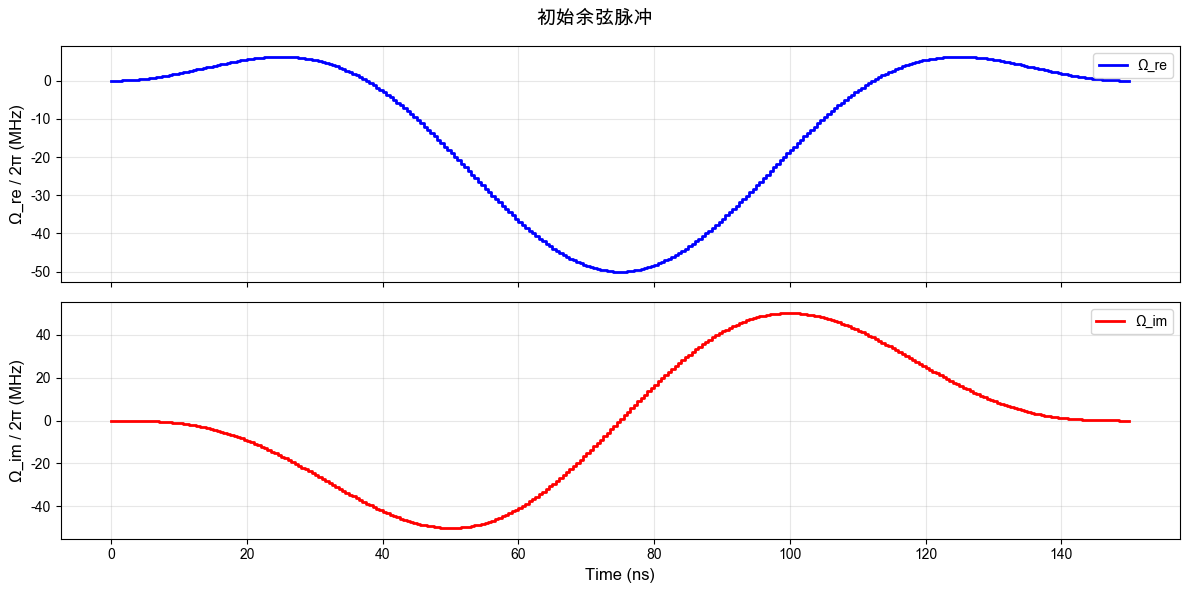

In [6]:
# 使用由余弦函数构造的脉冲
pulses_init_cos = cosine_pulse(n_steps=grader.n_steps)

plot_pulses(pulses_init_cos, grader.n_steps, grader.dt, title="初始余弦脉冲")

# 在封闭系统中优化，不考虑环境噪声
# 封闭系统的优化器，使用 jax 库实现，可快速优化初始脉冲到最优状态
# 优化器相关参数由题目给定，可进去源代码查看
grape_closed = TwoQubitGRAPE()

time_closed = time.time()
result = grape_closed.optimize(
    pulses_init_cos,
    maxiter=5000,
    disp=True
)
time_closed = time.time() - time_closed
print(f"封闭系统优化耗时: {time_closed:.2f} 秒")

# 优化后的最优封闭系统脉冲
pulses_closed = result.pulses



Simulating with 10 shots for ensemble averaging...

PULSE GRADING RESULTS (Two-Qubit CNOT - Dispersive Limit)

---------------------------PRIMARY METRICS----------------------------
Gate Error (ε_g):           0.025676
Gate Fidelity (1-ε_g):      0.974324 (97.4324%)
Leakage (L):                0.008008 (0.8008%)

------------------------PULSE QUALITY METRICS-------------------------
Amplitude Penalty (P_a):    0.005382
Derivative Penalty (P_d):   0.231969
Total Penalty:              0.237351

--------------------------SCORING COMPONENTS--------------------------
Gate Fidelity Score (80%):  0.974324
Leakage Score (15%):        0.959959
Penalty Score (5%):         0.762649

------------INDIVIDUAL STATE FIDELITIES (36 input states)-------------
       0       1       +       -      +i      -i  
 0  0.9795  0.9773  0.9861  0.9699  0.9728  0.9812
 1  0.9765  0.9771  0.9821  0.9740  0.9709  0.9810
 +  0.9741  0.9703  0.9787  0.9732  0.9687  0.9770
 -  0.9755  0.9703  0.9812  0.9704  0.9695 

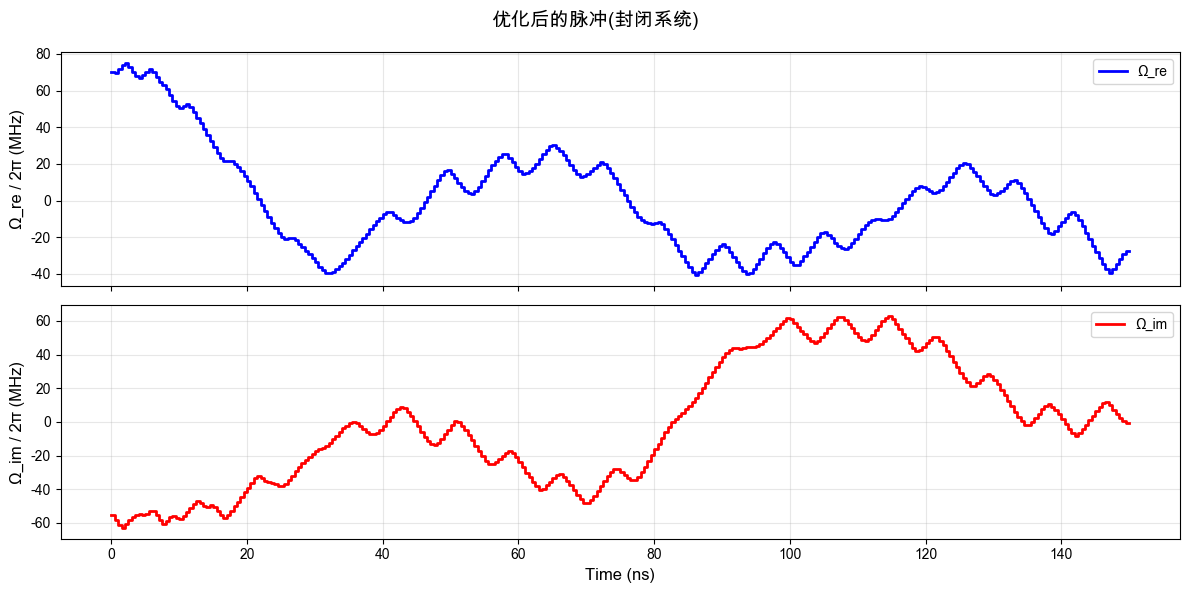

In [7]:
# 计算在开放系统中的评分
score_closed = grader.grade_submission(pulses_closed, n_shots=10, seed=518,verbose=True)

# 绘制优化后的脉冲
plot_pulses(pulses_closed, grader.n_steps, grader.dt, title="优化后的脉冲(封闭系统)")


In [8]:
# 基于封闭系统的脉冲，进行进一步优化
time_start = time.time()
# 开始优化, 并获得过程中的迭代记录
pulses_closed_opt, closed_iter_hist = optimizer.run(
    iters=iters,
    shots=n_shots,
    seeds=[518],
    pulses_init=pulses_closed,
    file_name="closed_opt",
    verbose=True # 打印每次的迭代信息
)
time_end = time.time()
print(f"封闭系统脉冲优化耗时：{time_end - time_start:.4f} 秒")

计算初始分数...
初始分数: 0.961586, 初始消耗时间: 29.06s
开始优化迭代...
x shape: (600,)
[SPSA] iter=   1 score=0.961306 best=0.961306 ak=2.361e-03 ck=1.000e-02 iter_time=90.13s
[SPSA] iter=   2 score=0.961123 best=0.961306 ak=2.240e-03 ck=9.324e-03 iter_time=88.93s
[SPSA] iter=   3 score=0.961122 best=0.961306 ak=2.135e-03 ck=8.950e-03 iter_time=88.60s
[SPSA] iter=   4 score=0.961124 best=0.961306 ak=2.042e-03 ck=8.693e-03 iter_time=88.22s
[SPSA] iter=   5 score=0.961114 best=0.961306 ak=1.959e-03 ck=8.500e-03 iter_time=93.41s
[SPSA] iter=   6 score=0.961111 best=0.961306 ak=1.884e-03 ck=8.345e-03 iter_time=93.30s
[SPSA] iter=   7 score=0.961117 best=0.961306 ak=1.817e-03 ck=8.216e-03 iter_time=93.35s
[SPSA] iter=   8 score=0.961082 best=0.961306 ak=1.755e-03 ck=8.106e-03 iter_time=92.74s
[SPSA] iter=   9 score=0.960940 best=0.961306 ak=1.699e-03 ck=8.010e-03 iter_time=92.74s
[SPSA] iter=  10 score=0.960932 best=0.961306 ak=1.647e-03 ck=7.925e-03 iter_time=93.00s
[SPSA] iter=  11 score=0.960856 best=0.9613

从优化过程，我们可以看到，每一次迭代得到的分数都不一定比初始脉冲的分数更好，即使优化前后两个脉冲之间存在差距，但脉冲数值量级可达 $10^{8}$。或许，是因为优化空间过大，我们选择的方案优化能力有限，暂时找不到更好的解。

In [9]:
# 查看两个波形，最大的绝对差异
print(np.abs(pulses_closed_opt - pulses_closed).max())
print(np.abs(pulses_closed_opt - pulses_closed).min())
print(np.abs(pulses_closed).max())
print(np.abs(pulses_closed).min())

816022.0184752867
701118.9913067818
471897575.6783068
1063184.9497618133


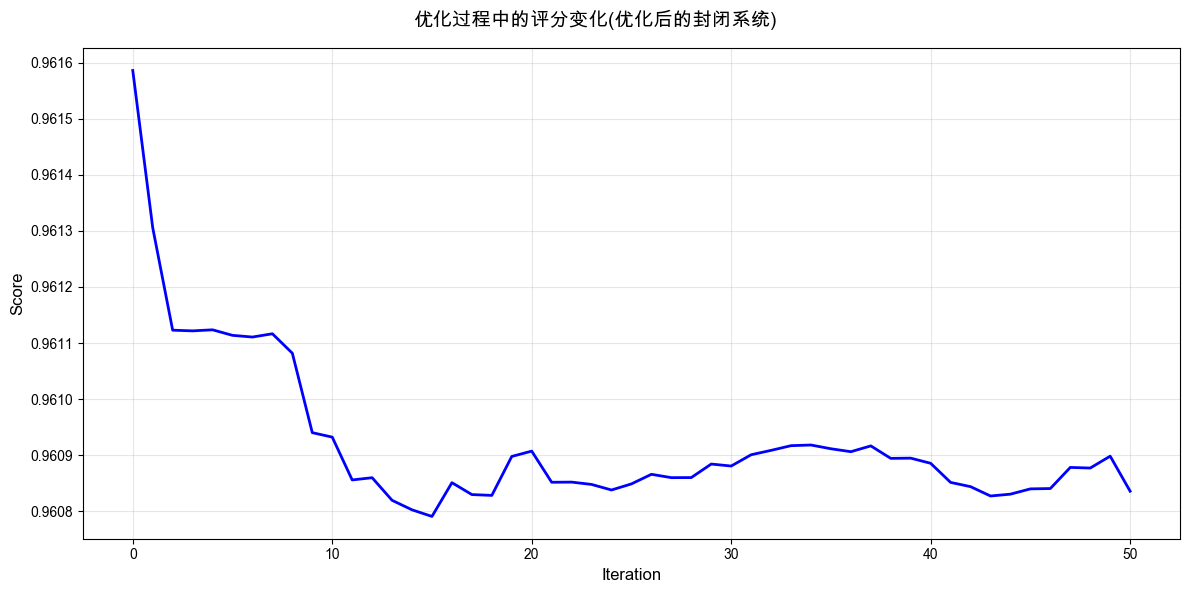

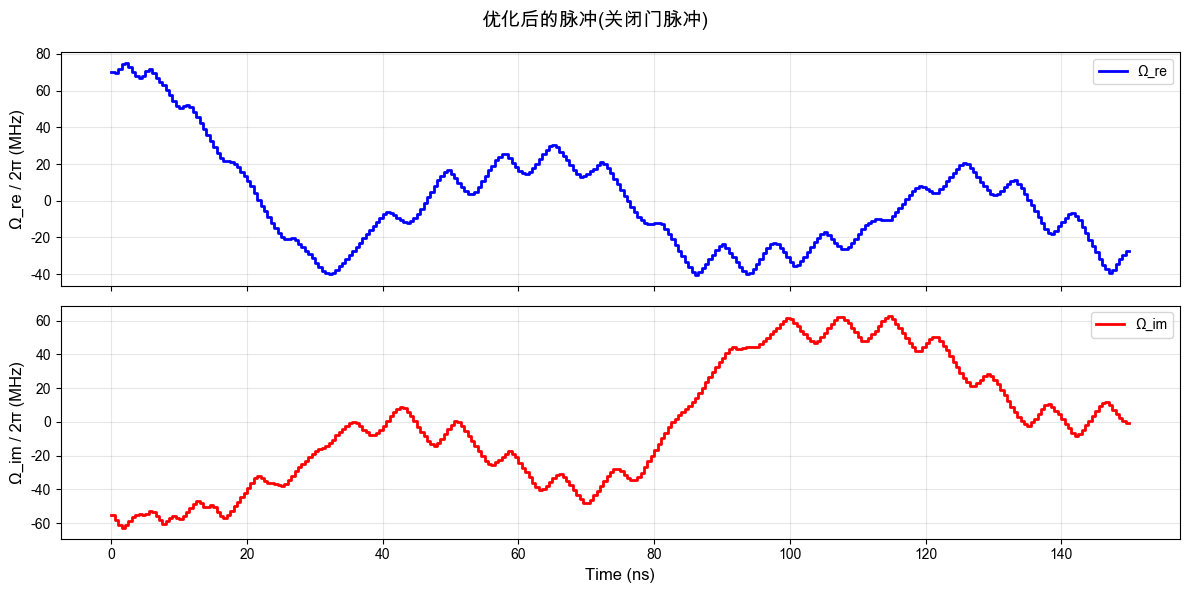

In [11]:
# 绘制迭代过程中的评分变化
plot_iter_hist(closed_iter_hist, title="优化过程中的评分变化(优化后的封闭系统)")
plot_pulses(pulses_closed_opt, grader.n_steps, grader.dt, title="优化后的脉冲(关闭门脉冲)")


##### 脉冲鲁棒性

使用封闭系统脉冲及其在开放系统中优化后的脉冲，基于随机的评分器种子数 seed（影响噪声的作用），随机运行100次 `grader.grade_submission`，统计平均评分、门错误、门保真度、泄漏和惩罚，查看脉冲针对不同噪声影响下的鲁棒性。


In [12]:
# 准备并行计算参数
iters_num = 100
args_list_closed = [(pulses_closed, False) for _ in range(iters_num)]
args_list_closed_optimized = [(pulses_closed_opt, False) for _ in range(iters_num)]

# 使用多进程并行计算
start_time = time.time()
with Pool() as pool:
    # 并行计算两组脉冲的评分
    # evaluate_pulse 中评分器是串行计算
    results_closed = pool.map(evaluate_pulse, args_list_closed)
    results_closed_optimized = pool.map(evaluate_pulse, args_list_closed_optimized)
end_time = time.time()
print(f"并行计算耗时: {end_time - start_time:.2f} 秒")


并行计算耗时: 12457.20 秒


In [13]:
# 提取结果
score_list_closed = [r[0] for r in results_closed]
gate_error_list_closed = [r[1] for r in results_closed]
gate_fidelity_list_closed = [r[2] for r in results_closed]
leakage_list_closed = [r[3] for r in results_closed]
penalty_list_closed = [r[4] for r in results_closed]

score_list_closed_optimized = [r[0] for r in results_closed_optimized]
gate_error_list_closed_optimized = [r[1] for r in results_closed_optimized]
gate_fidelity_list_closed_optimized = [r[2] for r in results_closed_optimized]
leakage_list_closed_optimized = [r[3] for r in results_closed_optimized]
penalty_list_closed_optimized = [r[4] for r in results_closed_optimized]

# 打印统计信息
print("\n=== pulses_spsa_closed 统计信息 ===")
print(f"平均评分: {np.mean(score_list_closed):.6f} ± {np.std(score_list_closed):.6f} max: {np.max(score_list_closed):.6f}, min: {np.min(score_list_closed):.6f}")
print(f"门错误: {np.mean(gate_error_list_closed):.6f} ± {np.std(gate_error_list_closed):.6f}")
print(f"门保真度: {np.mean(gate_fidelity_list_closed):.6f} ± {np.std(gate_fidelity_list_closed):.6f}")
print(f"泄漏: {np.mean(leakage_list_closed):.6f} ± {np.std(leakage_list_closed):.6f}")
print(f"惩罚: {np.mean(penalty_list_closed):.6f} ± {np.std(penalty_list_closed):.6f}")

print("\n=== pulses_spsa_closed_optimized 统计信息 ===")
print(f"平均评分: {np.mean(score_list_closed_optimized):.6f} ± {np.std(score_list_closed_optimized):.6f} max: {np.max(score_list_closed_optimized):.6f}, min: {np.min(score_list_closed_optimized):.6f}")
print(f"门错误: {np.mean(gate_error_list_closed_optimized):.6f} ± {np.std(gate_error_list_closed_optimized):.6f}")
print(f"门保真度: {np.mean(gate_fidelity_list_closed_optimized):.6f} ± {np.std(gate_fidelity_list_closed_optimized):.6f}")
print(f"泄漏: {np.mean(leakage_list_closed_optimized):.6f} ± {np.std(leakage_list_closed_optimized):.6f}")
print(f"惩罚: {np.mean(penalty_list_closed_optimized):.6f} ± {np.std(penalty_list_closed_optimized):.6f}")




=== pulses_spsa_closed 统计信息 ===
平均评分: 0.952899 ± 0.007655 max: 0.968634, min: 0.929103
门错误: 0.033348 ± 0.008902
门保真度: 0.966652 ± 0.008902
泄漏: 0.942968 ± 0.015030
惩罚: 0.762649 ± 0.000000

=== pulses_spsa_closed_optimized 统计信息 ===
平均评分: 0.952486 ± 0.006413 max: 0.967389, min: 0.933810
门错误: 0.033692 ± 0.007671
门保真度: 0.966308 ± 0.007671
泄漏: 0.943935 ± 0.015692
惩罚: 0.756991 ± 0.000000


我们注意到，优化前的脉冲 `pulses_closed`，在 100 次评分中，其各项参数相比于优化后的脉冲 `pulses_closed_opt` 均分更高，但其标准差略差，说明经过优化后，脉冲的鲁棒性有所改善。

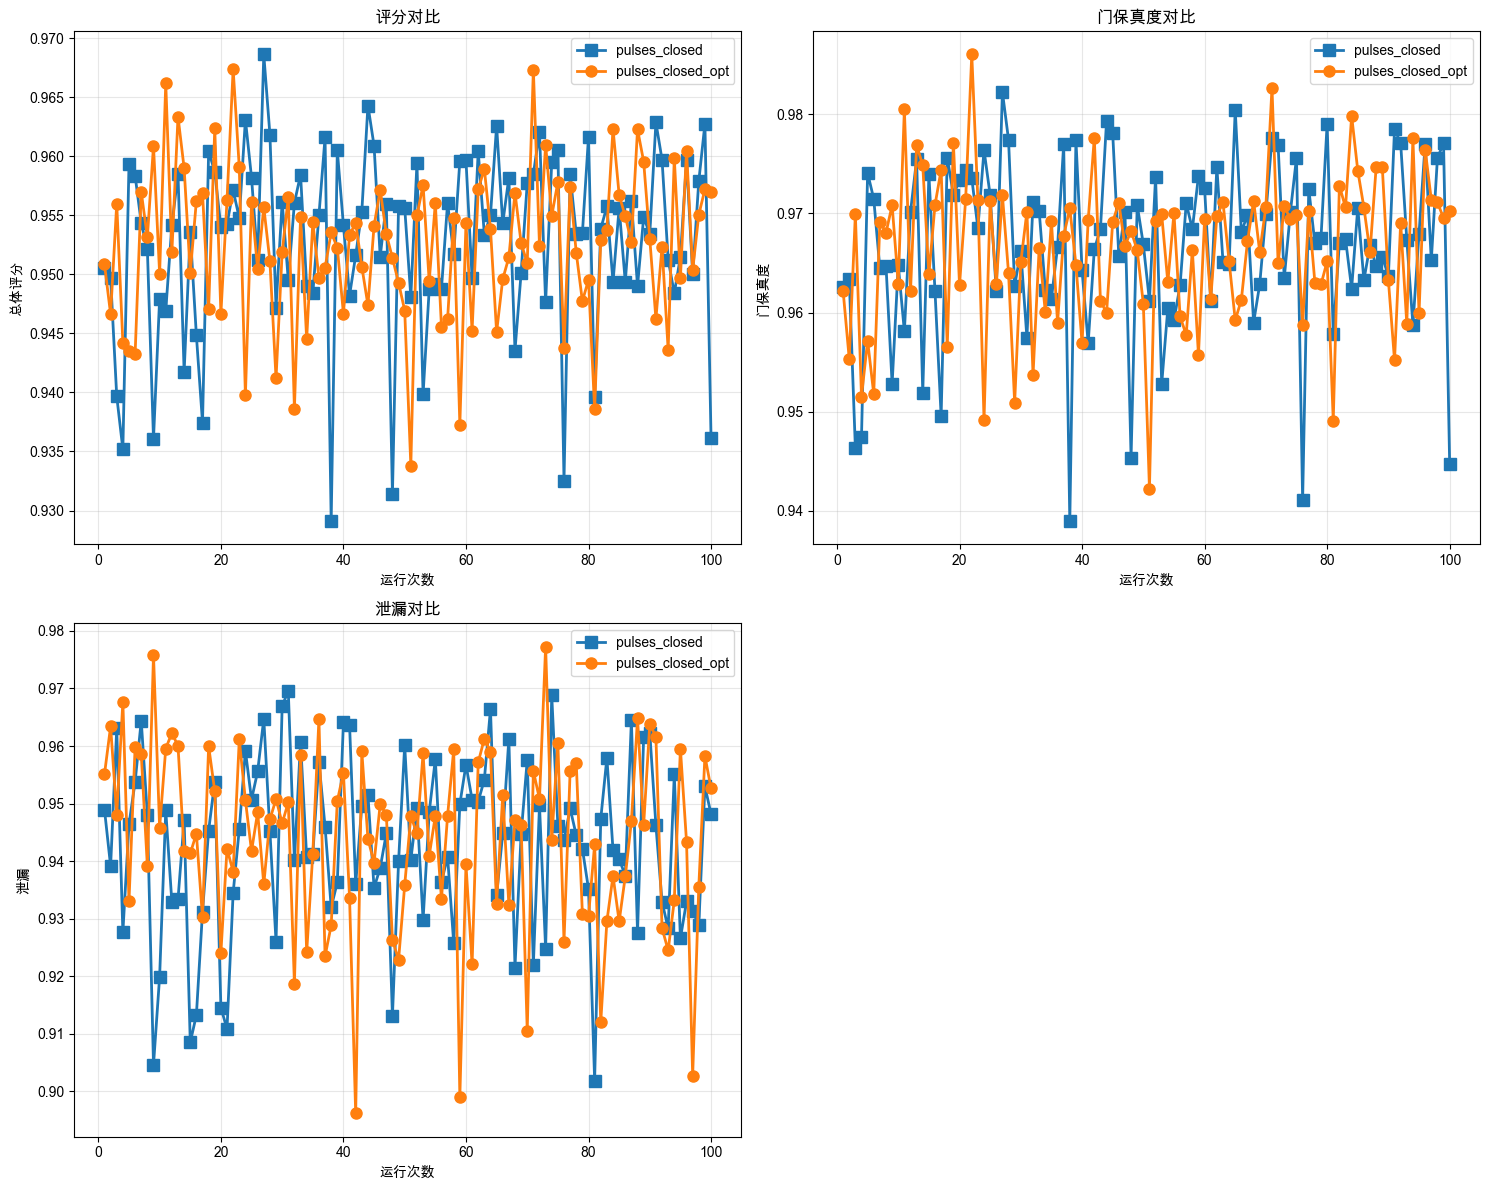

In [14]:
# 绘制详细结果
plt.figure(figsize=(15, 12))

# 子图1: 评分对比
plt.subplot(2, 2, 1)
plt.plot(range(1, iters_num+1), score_list_closed, 's-', label='pulses_closed', linewidth=2, markersize=8)
plt.plot(range(1, iters_num+1), score_list_closed_optimized, 'o-', label='pulses_closed_opt', linewidth=2, markersize=8)
plt.xlabel('运行次数')
plt.ylabel('总体评分')
plt.title('评分对比')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图2: 门保真度对比
plt.subplot(2, 2, 2)
plt.plot(range(1, iters_num+1), gate_fidelity_list_closed, 's-', label='pulses_closed', linewidth=2, markersize=8)
plt.plot(range(1, iters_num+1), gate_fidelity_list_closed_optimized, 'o-', label='pulses_closed_opt', linewidth=2, markersize=8)
plt.xlabel('运行次数')
plt.ylabel('门保真度')
plt.title('门保真度对比')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图3: 泄漏对比
plt.subplot(2, 2, 3)
plt.plot(range(1, iters_num+1), leakage_list_closed, 's-', label='pulses_closed', linewidth=2, markersize=8)
plt.plot(range(1, iters_num+1), leakage_list_closed_optimized, 'o-', label='pulses_closed_opt', linewidth=2, markersize=8)
plt.xlabel('运行次数')
plt.ylabel('泄漏')
plt.title('泄漏对比')
plt.legend()
plt.grid(True, alpha=0.3)

# # 子图4: 惩罚对比
# plt.subplot(2, 2, 4)
# plt.plot(range(1, iters_num+1), penalty_list_best, 's-', label='pulses_best', linewidth=2, markersize=8)
# plt.plot(range(1, iters_num+1), penalty_list_best_optimized, 'o-', label='pulses_best_opt', linewidth=2, markersize=8)
# plt.xlabel('运行次数')
# plt.ylabel('惩罚')
# plt.title('惩罚对比')
# plt.legend()
# plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### 最佳脉冲

从鲁棒性实验结果来看，尽管从标准差的角度来看，优化前的脉冲 `pulses_closed` 略差，但其各项参数的平均值更好。所以，在这里我们将其命名为 `cnot_pulses_best` 进行存储，作为我们双比特门的最佳脉冲，实际上使用优化后的脉冲也是可以的。

In [17]:
np.save("results/cnot_pulses_best.npy", pulses_closed)

### 经验总结

- 在封闭系统中优化脉冲，初始脉冲要选好，否则即使添加 Derivative Penalty 到损失函数中，也会导致惩罚项 Derivative Penalty 溢出，该数值主要取决于脉冲前后两点的差值，即 $ pulse_{i+1,n} - pulse_{i,n}$;
- 除了 spsa 随机梯度优化外，我们还尝试了 nelder-mead 无梯度优化、强化学习、参数化等方案，但效果均不行，分数无显著提升；